Task 1: Data Collection & Dataset Understanding

In [ ]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [6]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


The Netflix dataset contains information about movies and TV shows available on Netflix. It includes details such as title, director, country, release year, rating, and genre. The dataset helps analyze content trends and viewing categories. 

Task 2: Data Cleaning & Preprocessing

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [11]:
df.drop_duplicates(inplace=True)

In [13]:
df['date_added'].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: str

In [14]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [16]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [17]:
df.to_csv("cleaned_netflix.csv", index=False)

Task 3: Exploratory Data Analysis (EDA)

In [18]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [19]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [20]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [21]:
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

Findings

Examples:

Netflix contains more Movies than TV Shows.
The United States contributes the most content.
TV-MA is one of the most common ratings.
Content production increased significantly after 2015.

Task 4: Data Visualization


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

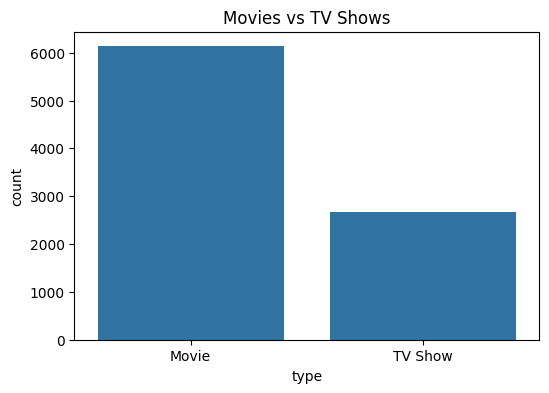

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

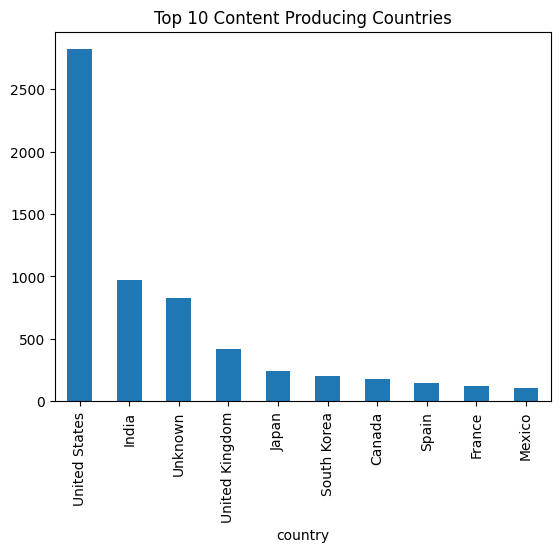

In [24]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

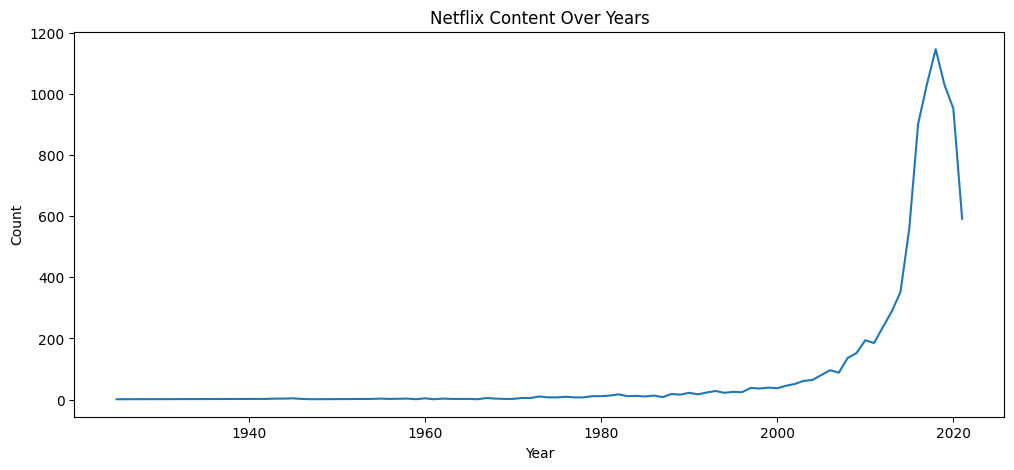

In [25]:
df['release_year'].value_counts().sort_index().plot(figsize=(12,5))
plt.title("Netflix Content Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

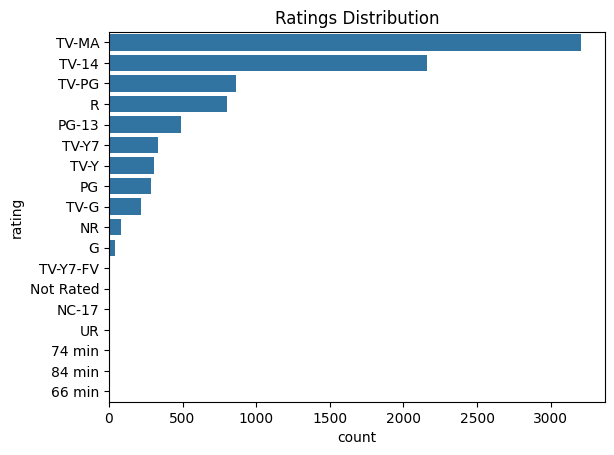

In [26]:
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Ratings Distribution")
plt.show()

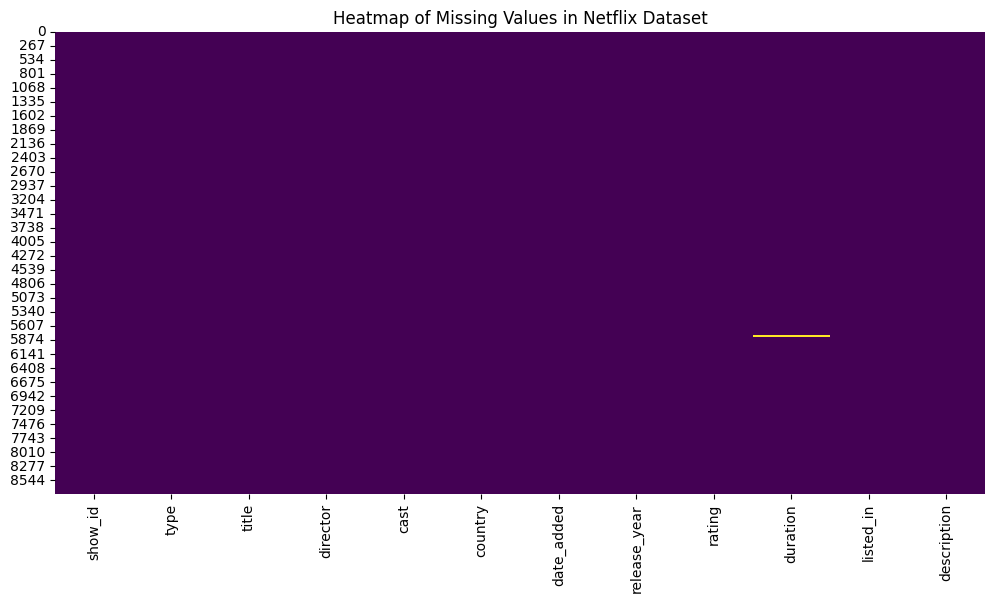

In [43]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Heatmap of Missing Values in Netflix Dataset")
plt.show()

In [57]:
total_titles = df.shape[0]
movies = (df['type'] == 'Movie').sum()
tv_shows = (df['type'] == 'TV Show').sum()

print("📌 Netflix Dataset Dashboard")
print("-" * 40)
print("Total Titles:", total_titles)
print("Movies:", movies)
print("TV Shows:", tv_shows)
print("Movies %:", round(movies/total_titles*100, 2))
print("TV Shows %:", round(tv_shows/total_titles*100, 2))

📌 Netflix Dataset Dashboard
----------------------------------------
Total Titles: 8807
Movies: 6131
TV Shows: 2676
Movies %: 69.62
TV Shows %: 30.38


Task 5: Machine Learning Model

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [59]:
df_movies = df[df['type'] == 'Movie'].copy()

df_movies['duration_num'] = (
    df_movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

In [60]:
X = df_movies[['duration_num']]
y = df_movies['release_year']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
df_movies = df_movies.dropna(subset=['duration_num', 'release_year'])

In [63]:
print(df_movies[['duration_num', 'release_year']].isnull().sum())

duration_num    0
release_year    0
dtype: int64


In [64]:
X = df_movies[['duration_num']]
y = df_movies['release_year']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
predictions = model.predict(X_test)

“A simple Linear Regression model was used to demonstrate predictive analysis on Netflix movie duration vs release year. Missing values were handled before training.”

Conclusion

This project analyzed Netflix movies and TV shows using Data Science techniques. Data cleaning was performed to improve data quality, exploratory analysis identified content trends, visualizations highlighted important patterns, A heatmap was used to visualize missing values in the dataset. It helps quickly identify incomplete data columns. The analysis shows that columns such as director, cast, and country contain significant missing values, which were handled during preprocessing. and a machine learning model was developed to demonstrate predictive analysis. The project successfully demonstrates the complete data science workflow from raw data to actionable insights.

In [1]:
pip install streamlit


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
